<a href="https://colab.research.google.com/github/TcheugoueGilbert/deforestation_analysis/blob/main/d_forestation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loading data...
Dataset shape: (157779, 15)

First few rows:
   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0   34.6904    10.7310       304.5   1.0    1.0  2001-02-01      1018   
1   36.8587     9.7768       300.3   1.5    1.2  2001-02-03      1005   
2   36.5027     9.6095       320.6   1.3    1.1  2001-05-04      1040   
3   33.8598     8.0310       349.3   1.4    1.2  2001-06-02      1010   
4   36.8317    10.0124       301.6   1.1    1.0  2001-06-05      2142   

  satellite instrument  confidence version  bright_t31   frp daynight  type  
0     Terra      MODIS           0    6.03       289.6   4.2        D   2.0  
1     Terra      MODIS          33    6.03       285.5   9.1        D   0.0  
2     Terra      MODIS          73    6.03       300.5  13.8        D   0.0  
3     Terra      MODIS          93    6.03       312.9  74.4        D   0.0  
4     Terra      MODIS          43    6.03       290.0   5.9        N   2.0  

Data types:
latitude      float

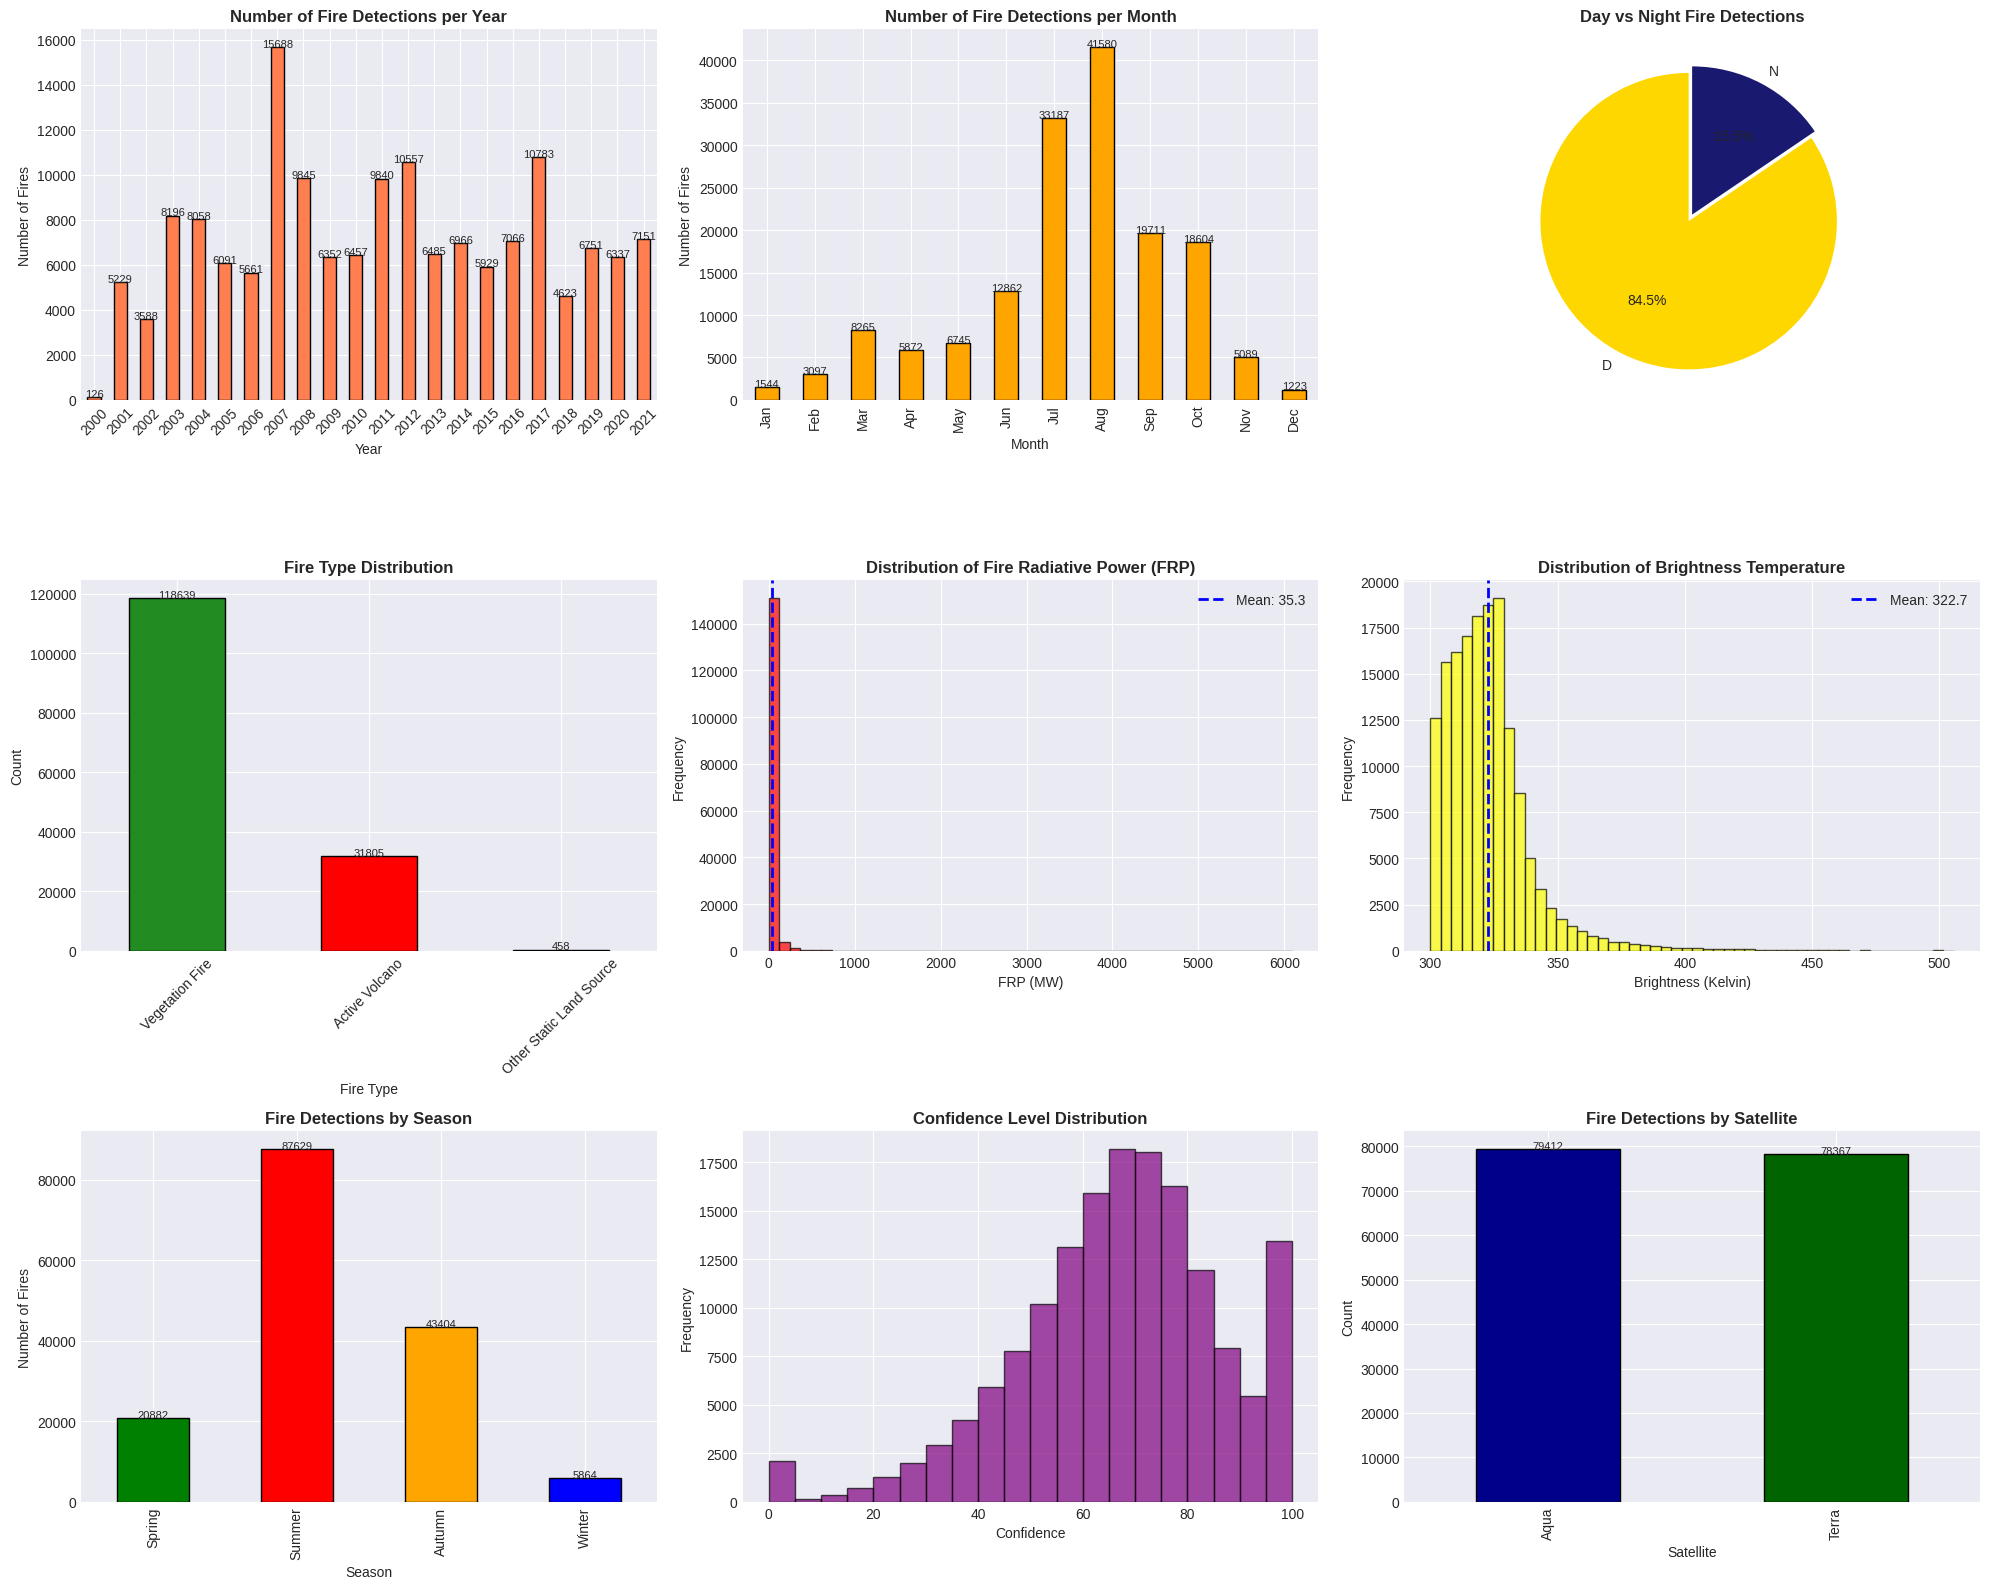


Generating correlation heatmap...


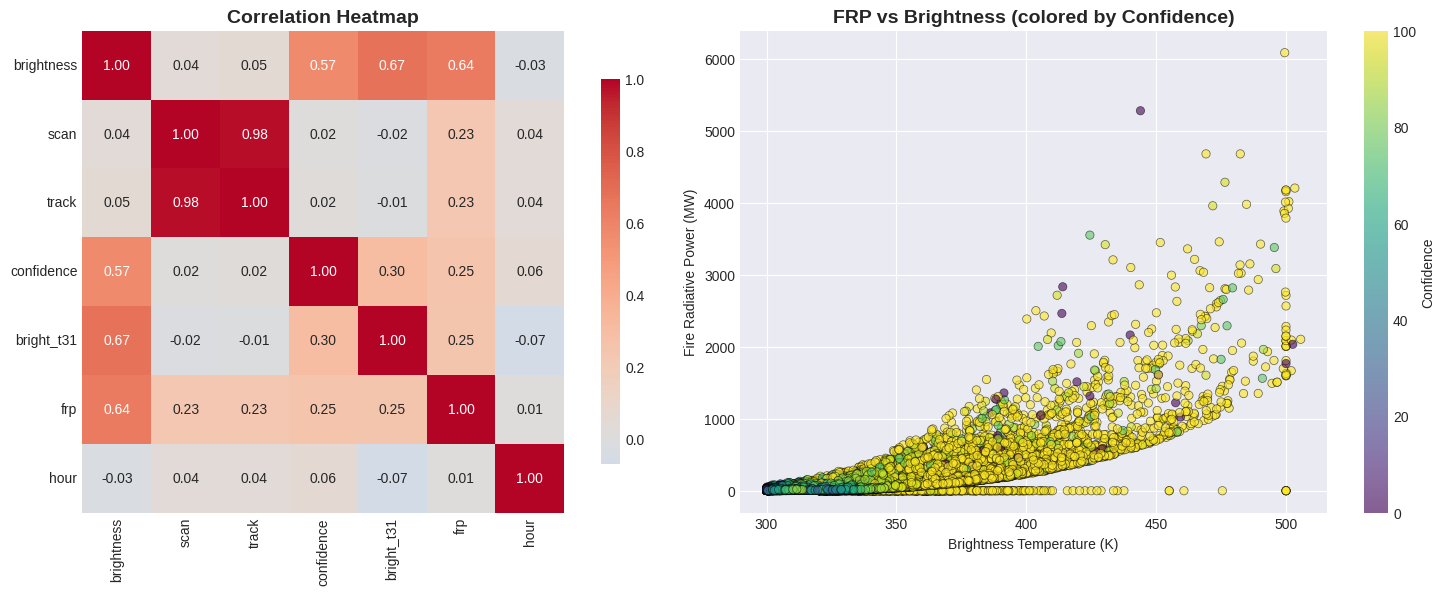


Generating time series analysis...


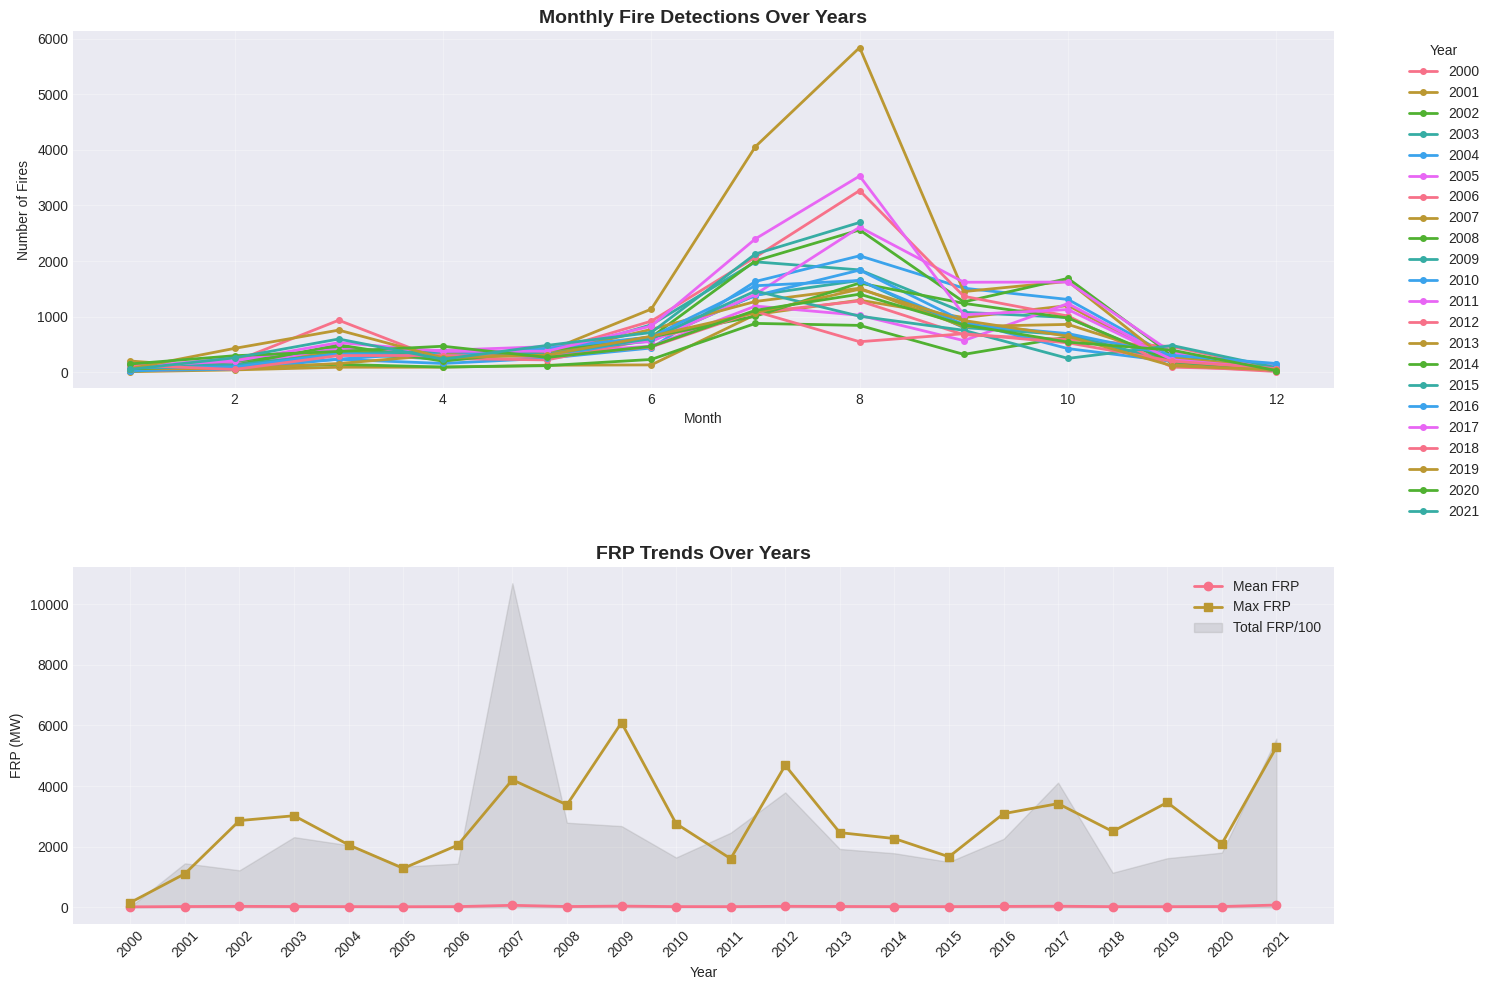


Preparing spatial visualization...


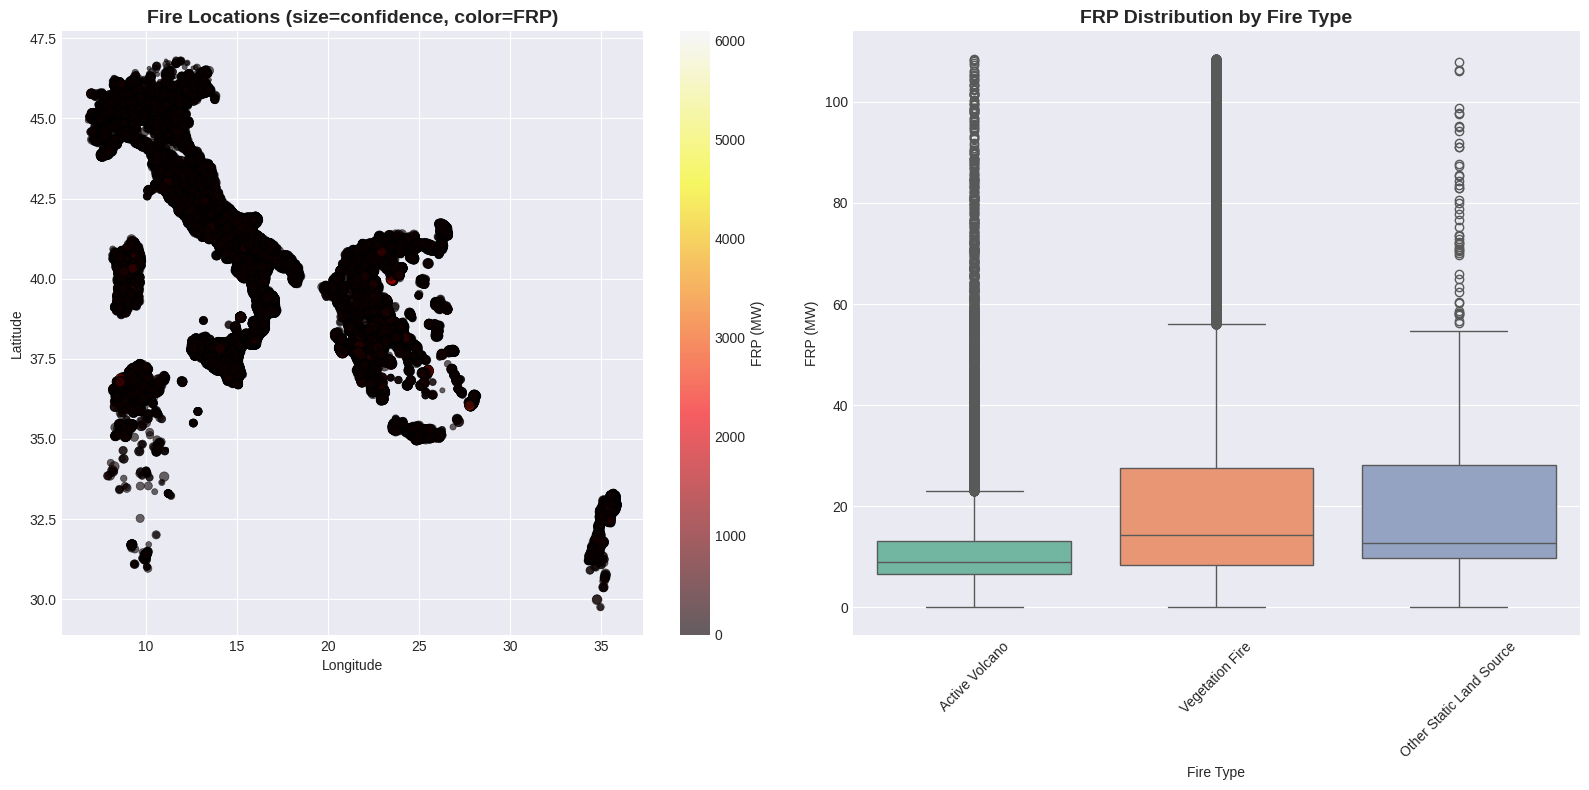


STATISTICAL SUMMARY

Top 10 highest FRP events:
        acq_date  latitude  longitude      frp  brightness  confidence
24982 2009-08-17  38.26690   22.94910  6091.70      499.50         100
43312 2021-08-04  38.81009   23.25347  5284.64      443.96           0
30491 2012-08-08  40.32450   24.05480  4684.60      469.20         100
24972 2009-08-17  38.26040   22.95430  4684.30      482.40         100
24977 2009-08-17  38.26050   22.92120  4289.40      476.50          94
18283 2007-08-25  37.32470   22.21730  4209.00      503.40         100
43963 2021-08-06  38.86206   23.22690  4183.11      499.97         100
43956 2021-08-06  38.86605   23.22023  4180.29      499.97         100
43957 2021-08-06  38.87037   23.24061  4159.18      499.97         100
18273 2007-08-25  37.29500   22.15600  4020.70      501.10         100

Fire detection by time of day:
time_category
Morning (6-12)       92855
Afternoon (12-18)    40451
Evening (18-24)      15965
Night (0-6)           8500
Name: count, dty

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. LOAD THE DATA
print("Loading data...")
df_tunisia = pd.read_csv('TUNISIA_2000_2021_M-C61_214281.csv')
df_greece = pd.read_csv('GREECE_2000_2021 - fire_archive_M-C61_214279.csv')
df_italy = pd.read_csv('ITALY_2000_2021 - fire_archive_M-C61_214280.csv')
df_israel = pd.read_csv('ISRAEL_2000_2021 - fire_archive_M-C61_214285.csv')


df = pd.concat([df_tunisia, df_greece, df_italy, df_israel], ignore_index=True)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

# 2. DATA CLEANING
print("\n" + "="*50)
print("DATA CLEANING")
print("="*50)

# Convert date column to datetime
df['acq_date'] = pd.to_datetime(df['acq_date'])

# Extract year, month, day from date
df['year'] = df['acq_date'].dt.year
df['month'] = df['acq_date'].dt.month
df['day'] = df['acq_date'].dt.day
df['day_of_year'] = df['acq_date'].dt.dayofyear

# Convert time to hour (24-hour format)
def time_to_hour(time_str):
    """Convert HHMM format to hour (float)"""
    if len(str(int(time_str))) == 3:
        return float(str(time_str).zfill(4)[:2]) + float(str(time_str).zfill(4)[2:])/60
    else:
        return float(str(time_str).zfill(4)[:2]) + float(str(time_str).zfill(4)[2:])/60

df['hour'] = df['acq_time'].apply(time_to_hour)

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['month'].apply(get_season)

# Convert type to categorical with meaningful labels
type_mapping = {
    0: 'Vegetation Fire',
    2: 'Active Volcano',
    3: 'Other Static Land Source'
}
df['type_label'] = df['type'].map(type_mapping)

# 3. EXPLORATORY DATA ANALYSIS
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# Basic statistics
print("\nBasic Statistics:")
print(df.describe())

print(f"\nTime range: {df['acq_date'].min()} to {df['acq_date'].max()}")
print(f"Satellites: {df['satellite'].unique()}")
print(f"Instruments: {df['instrument'].unique()}")
print(f"Day/Night distribution:\n{df['daynight'].value_counts()}")
print(f"\nFire type distribution:\n{df['type_label'].value_counts()}")

# 4. DATA VISUALIZATION
print("\n" + "="*50)
print("DATA VISUALIZATION")
print("="*50)

# Create a figure with subplots
fig = plt.figure(figsize=(20, 16))

# 4.1 Temporal Analysis - Fires per year
ax1 = plt.subplot(3, 3, 1)
fires_per_year = df.groupby('year').size()
fires_per_year.plot(kind='bar', ax=ax1, color='coral', edgecolor='black')
ax1.set_title('Number of Fire Detections per Year', fontsize=12, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Fires')
ax1.tick_params(axis='x', rotation=45)
for i, v in enumerate(fires_per_year):
    ax1.text(i, v + 3, str(v), ha='center', fontsize=8)

# 4.2 Temporal Analysis - Fires per month
ax2 = plt.subplot(3, 3, 2)
fires_per_month = df.groupby('month').size()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
fires_per_month.index = month_names
fires_per_month.plot(kind='bar', ax=ax2, color='orange', edgecolor='black')
ax2.set_title('Number of Fire Detections per Month', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Fires')
for i, v in enumerate(fires_per_month):
    ax2.text(i, v + 3, str(v), ha='center', fontsize=8)

# 4.3 Day vs Night fires
ax3 = plt.subplot(3, 3, 3)
daynight_counts = df['daynight'].value_counts()
colors = ['gold', 'midnightblue']
daynight_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', colors=colors,
                    startangle=90, explode=(0.05, 0))
ax3.set_title('Day vs Night Fire Detections', fontsize=12, fontweight='bold')
ax3.set_ylabel('')

# 4.4 Fire types distribution
ax4 = plt.subplot(3, 3, 4)
type_counts = df['type_label'].value_counts()
type_counts.plot(kind='bar', ax=ax4, color=['forestgreen', 'red', 'gray'], edgecolor='black')
ax4.set_title('Fire Type Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Fire Type')
ax4.set_ylabel('Count')
ax4.tick_params(axis='x', rotation=45)
for i, v in enumerate(type_counts):
    ax4.text(i, v + 3, str(v), ha='center', fontsize=8)

# 4.5 FRP (Fire Radiative Power) distribution
ax5 = plt.subplot(3, 3, 5)
df['frp'].hist(bins=50, ax=ax5, color='red', edgecolor='black', alpha=0.7)
ax5.set_title('Distribution of Fire Radiative Power (FRP)', fontsize=12, fontweight='bold')
ax5.set_xlabel('FRP (MW)')
ax5.set_ylabel('Frequency')
ax5.axvline(df['frp'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df["frp"].mean():.1f}')
ax5.legend()

# 4.6 Brightness distribution
ax6 = plt.subplot(3, 3, 6)
df['brightness'].hist(bins=50, ax=ax6, color='yellow', edgecolor='black', alpha=0.7)
ax6.set_title('Distribution of Brightness Temperature', fontsize=12, fontweight='bold')
ax6.set_xlabel('Brightness (Kelvin)')
ax6.set_ylabel('Frequency')
ax6.axvline(df['brightness'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df["brightness"].mean():.1f}')
ax6.legend()

# 4.7 Seasonal distribution
ax7 = plt.subplot(3, 3, 7)
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_counts = df['season'].value_counts().reindex(season_order)
season_counts.plot(kind='bar', ax=ax7, color=['green', 'red', 'orange', 'blue'], edgecolor='black')
ax7.set_title('Fire Detections by Season', fontsize=12, fontweight='bold')
ax7.set_xlabel('Season')
ax7.set_ylabel('Number of Fires')
for i, v in enumerate(season_counts):
    ax7.text(i, v + 3, str(v), ha='center', fontsize=8)

# 4.8 Confidence level distribution
ax8 = plt.subplot(3, 3, 8)
df['confidence'].hist(bins=20, ax=ax8, color='purple', edgecolor='black', alpha=0.7)
ax8.set_title('Confidence Level Distribution', fontsize=12, fontweight='bold')
ax8.set_xlabel('Confidence')
ax8.set_ylabel('Frequency')

# 4.9 Satellite distribution
ax9 = plt.subplot(3, 3, 9)
sat_counts = df['satellite'].value_counts()
sat_counts.plot(kind='bar', ax=ax9, color=['darkblue', 'darkgreen'], edgecolor='black')
ax9.set_title('Fire Detections by Satellite', fontsize=12, fontweight='bold')
ax9.set_xlabel('Satellite')
ax9.set_ylabel('Count')
for i, v in enumerate(sat_counts):
    ax9.text(i, v + 3, str(v), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# 5. HEATMAP AND CORRELATION ANALYSIS
print("\nGenerating correlation heatmap...")
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Select numerical columns for correlation
numerical_cols = ['brightness', 'scan', 'track', 'confidence',
                  'bright_t31', 'frp', 'hour']
corr_matrix = df[numerical_cols].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, ax=ax1, fmt='.2f', cbar_kws={'shrink': 0.8})
ax1.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# FRP vs Brightness scatter plot
scatter = ax2.scatter(df['brightness'], df['frp'],
                     c=df['confidence'], cmap='viridis',
                     alpha=0.6, edgecolors='black', linewidth=0.5)
ax2.set_xlabel('Brightness Temperature (K)')
ax2.set_ylabel('Fire Radiative Power (MW)')
ax2.set_title('FRP vs Brightness (colored by Confidence)', fontsize=14, fontweight='bold')
plt.colorbar(scatter, ax=ax2, label='Confidence')

plt.tight_layout()
plt.show()

# 6. TIME SERIES ANALYSIS
print("\nGenerating time series analysis...")
fig3, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

# Monthly fire counts over years
monthly_fires = df.groupby(['year', 'month']).size().unstack()
monthly_fires.T.plot(ax=ax1, linewidth=2, marker='o', markersize=4)
ax1.set_title('Monthly Fire Detections Over Years', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Fires')
ax1.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# FRP trend over years
yearly_frp = df.groupby('year')['frp'].agg(['mean', 'sum', 'max']).reset_index()
ax2.plot(yearly_frp['year'], yearly_frp['mean'], 'o-', label='Mean FRP', linewidth=2)
ax2.plot(yearly_frp['year'], yearly_frp['max'], 's-', label='Max FRP', linewidth=2)
ax2.fill_between(yearly_frp['year'], 0, yearly_frp['sum']/100,
                alpha=0.2, label='Total FRP/100', color='gray')
ax2.set_title('FRP Trends Over Years', fontsize=14, fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('FRP (MW)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(yearly_frp['year'])
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 7. SPATIAL VISUALIZATION PREPARATION
print("\nPreparing spatial visualization...")
fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Scatter plot of fire locations
scatter1 = ax1.scatter(df['longitude'], df['latitude'],
                      c=df['frp'], cmap='hot',
                      s=df['confidence']/2, alpha=0.6,
                      edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Fire Locations (size=confidence, color=FRP)', fontsize=14, fontweight='bold')
plt.colorbar(scatter1, ax=ax1, label='FRP (MW)')

# Boxplot of FRP by fire type
df_boxplot = df[df['frp'] < df['frp'].quantile(0.95)]  # Remove extreme outliers for better visualization
sns.boxplot(x='type_label', y='frp', data=df_boxplot, ax=ax2, palette='Set2')
ax2.set_title('FRP Distribution by Fire Type', fontsize=14, fontweight='bold')
ax2.set_xlabel('Fire Type')
ax2.set_ylabel('FRP (MW)')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 8. ADDITIONAL STATISTICAL SUMMARY
print("\n" + "="*50)
print("STATISTICAL SUMMARY")
print("="*50)

print("\nTop 10 highest FRP events:")
top_frp = df.nlargest(10, 'frp')[['acq_date', 'latitude', 'longitude', 'frp', 'brightness', 'confidence']]
print(top_frp)

print("\nFire detection by time of day:")
df['time_category'] = pd.cut(df['hour'],
                            bins=[0, 6, 12, 18, 24],
                            labels=['Night (0-6)', 'Morning (6-12)', 'Afternoon (12-18)', 'Evening (18-24)'])
print(df['time_category'].value_counts())

print(f"\nAverage FRP by fire type:")
print(df.groupby('type_label')['frp'].agg(['mean', 'median', 'max', 'count']))

print(f"\nAverage confidence by satellite:")
print(df.groupby('satellite')['confidence'].mean())

# 9. SAVE CLEANED DATA
print("\n" + "="*50)
print("SAVING PROCESSED DATA")
print("="*50)

# Create a cleaned version of the dataset
df_cleaned = df.copy()

# Save to new CSV file
output_file = 'TUNISIA_fires_cleaned.csv'
df_cleaned.to_csv(output_file, index=False)
print(f"Cleaned data saved to: {output_file}")

print("\n" + "="*50)
print("ANALYSIS COMPLETE!")
print("="*50)

# Display final dataset info
print(f"\nFinal dataset shape: {df_cleaned.shape}")
print(f"\nColumns in cleaned dataset:")
print(df_cleaned.columns.tolist())
print(f"\nSample of cleaned data:")
print(df_cleaned[['acq_date', 'latitude', 'longitude', 'frp', 'brightness', 'type_label', 'season']].head())

1. LOADING AND CLEANING DATA
Initial dataset shape: (154573, 15)

2. FEATURE ENGINEERING
New features created. Total features: 37

3. EXPLORATORY DATA ANALYSIS

Target variable distribution:

Fire Severity (Binary):
fire_severity
Low     77601
High    76972
Name: count, dtype: int64

FRP Statistics:
Mean FRP: 35.32
Median FRP: 13.30
Std FRP: 115.49


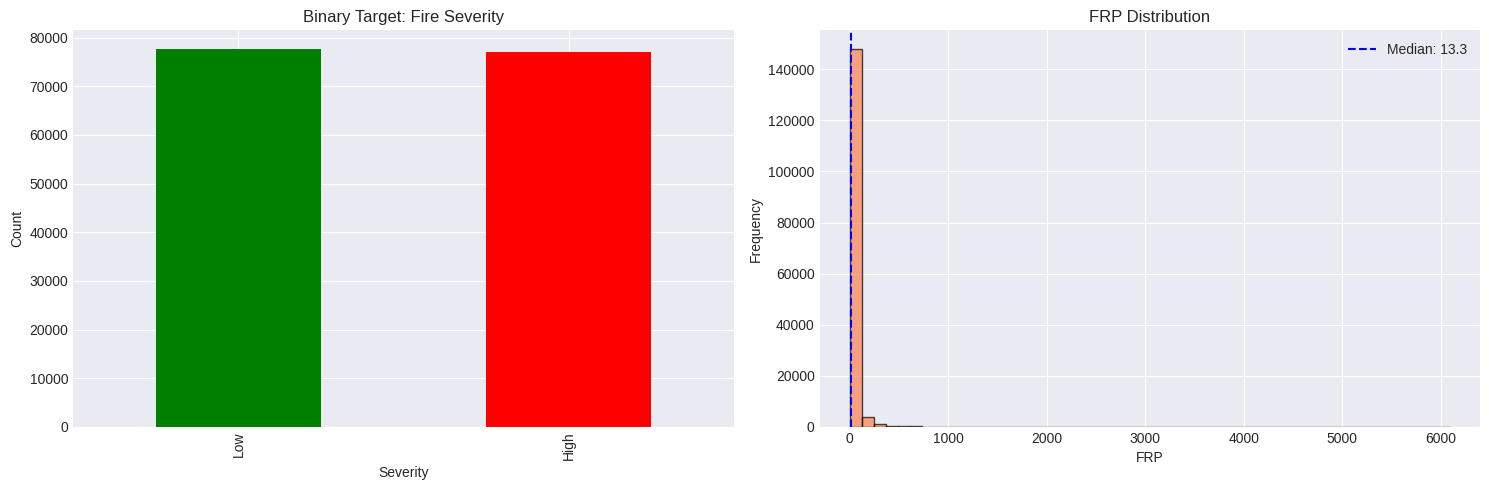


4. PREPARING DATA FOR MACHINE LEARNING
Total features for modeling: 21

Binary classes: ['High' 'Low']
Multi classes: ['Extreme' 'High' 'Low' 'Medium' nan]

Dataset sizes:
Binary Classification - Train: (123658, 21), Test: (30915, 21)
Multi-class Classification - Train: (123658, 21), Test: (30915, 21)
Regression - Train: (123658, 21), Test: (30915, 21)

5. CREATING PREPROCESSING PIPELINE
Preprocessing pipeline created successfully!

6. BINARY CLASSIFICATION (High vs Low Fire)

Logistic Regression:
  Accuracy: 0.9358
  Precision: 0.9360
  Recall: 0.9358
  F1-Score: 0.9358

Random Forest:
  Accuracy: 0.9520
  Precision: 0.9520
  Recall: 0.9520
  F1-Score: 0.9520

Gradient Boosting:
  Accuracy: 0.9449
  Precision: 0.9449
  Recall: 0.9449
  F1-Score: 0.9449

SVM:
  Accuracy: 0.9478
  Precision: 0.9478
  Recall: 0.9478
  F1-Score: 0.9478

K-Nearest Neighbors:
  Accuracy: 0.9237
  Precision: 0.9245
  Recall: 0.9237
  F1-Score: 0.9236

Decision Tree:
  Accuracy: 0.9291
  Precision: 0.9291
  

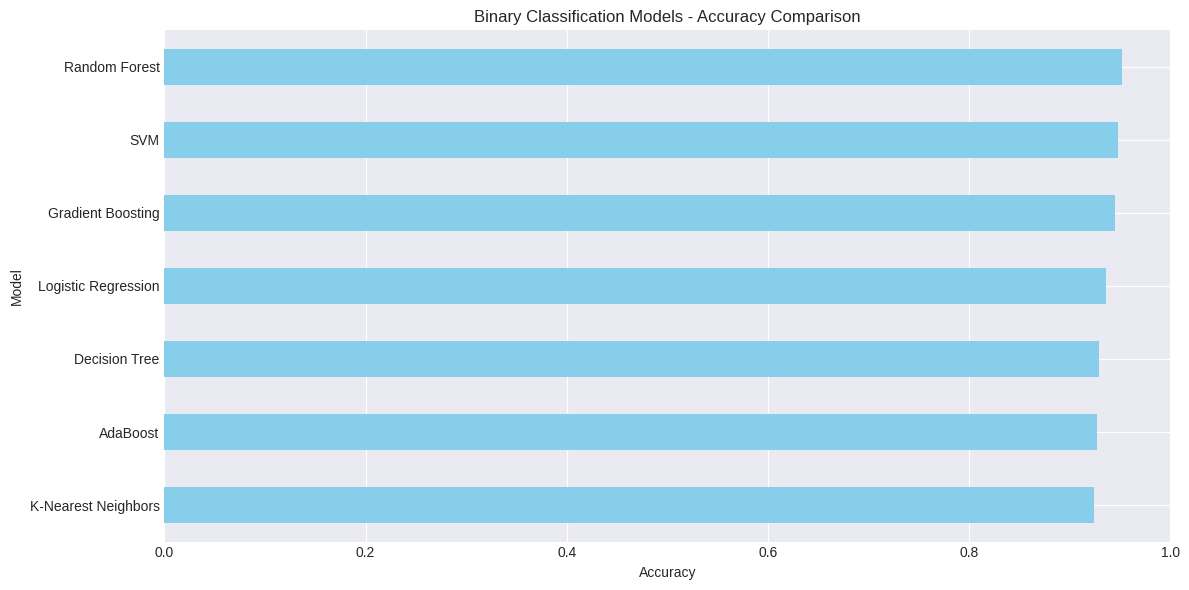


7. MULTI-CLASS CLASSIFICATION
Using top 3 models: ['Random Forest', 'SVM', 'Gradient Boosting']

Random Forest:
  Accuracy: 0.9253

SVM:
  Accuracy: 0.9015

Gradient Boosting:
  Accuracy: 0.9175

MULTI-CLASS CLASSIFICATION RESULTS
            Model  Accuracy
    Random Forest  0.925311
Gradient Boosting  0.917451
              SVM  0.901472

8. REGRESSION (Predicting log(FRP))

Linear Regression:
  RMSE: 217.8102
  MAE: 13.8315
  R² Score: -2.5334

Random Forest Regressor:
  RMSE: 25.3890
  MAE: 3.5931
  R² Score: 0.9520

Gradient Boosting Regressor:
  RMSE: 37.0016
  MAE: 5.0121
  R² Score: 0.8980

Ridge Regression:
  RMSE: 217.7906
  MAE: 13.8307
  R² Score: -2.5328

Lasso Regression:
  RMSE: 87.8148
  MAE: 12.5888
  R² Score: 0.4257

REGRESSION RESULTS
                      Model       RMSE       MAE  R2 Score
    Random Forest Regressor  25.389009  3.593150  0.951990
Gradient Boosting Regressor  37.001573  5.012113  0.898028
           Lasso Regression  87.814812 12.588755  0.4256

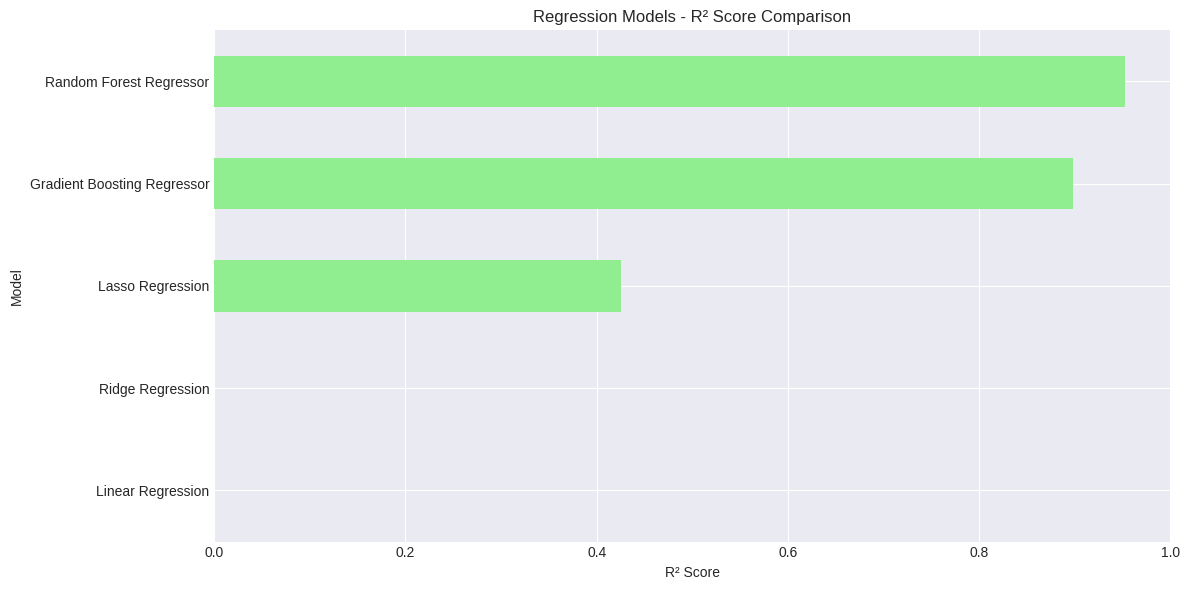


9. HYPERPARAMETER TUNING (Best Model)
Best Classification Model: Random Forest
Tuning Random Forest Classifier...
Best parameters: {'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best CV score: 0.9521
Test accuracy after tuning: 0.9523

10. FEATURE IMPORTANCE ANALYSIS
Analyzing feature importance with Random Forest...

Top 10 Most Important Features:
                    feature  importance
            brightness_diff    0.213334
                 brightness    0.147820
                 confidence    0.131328
                       scan    0.110454
           scan_track_ratio    0.101392
                      track    0.078970
                 bright_t31    0.036826
                   latitude    0.029870
brightness_hour_interaction    0.027487
                  longitude    0.020745


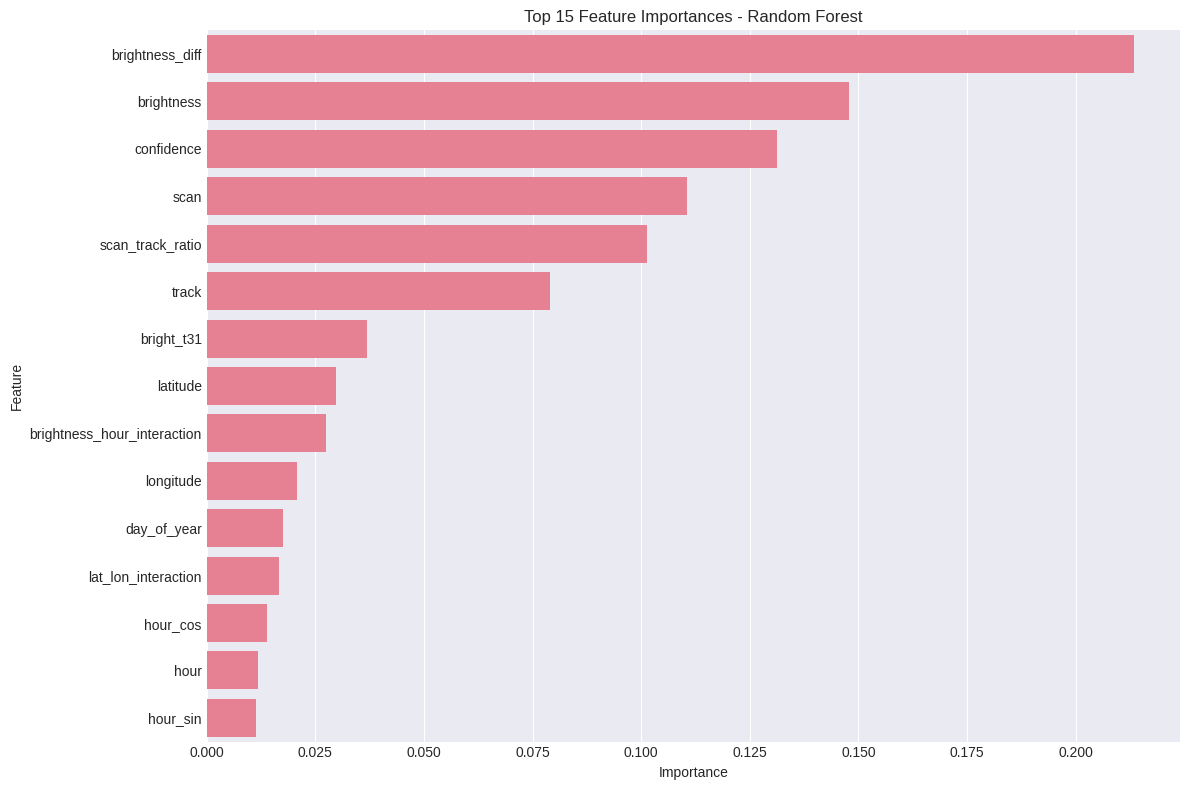


11. SAVING MODELS AND ARTIFACTS
✓ Best classification model saved to: saved_models/best_classification_model.pkl
✓ Best regression model saved to: saved_models/best_regression_model.pkl
✓ Preprocessing pipeline saved to: saved_models/preprocessor.pkl
✓ Label encoders saved to: saved_models/label_encoders.pkl
✓ Feature information saved to: saved_models/feature_info.json

12. PREDICTION FUNCTION
Testing prediction function...
Classification prediction: {'prediction': 'High', 'confidence': 0.5677097186263377, 'probabilities': {'High': 0.5677097186263377, 'Low': 0.4322902813736624}, 'model_type': 'classification'}
Regression prediction: {'prediction': 12.550102909948448, 'prediction_log': 2.606394142127013, 'model_type': 'regression'}

13. FINAL SUMMARY

🏆 BEST MODEL PERFORMANCE:
------------------------------

Classification (Binary):
  Model: Random Forest
  Accuracy: 0.9520
  F1-Score: 0.9520

Regression:
  Model: Random Forest Regressor
  R² Score: 0.9520
  RMSE: 25.39

📊 KEY INSIGHT

In [3]:
# COMPLETE MACHINE LEARNING PIPELINE FOR FOREST FIRE DATA
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           roc_auc_score, confusion_matrix, classification_report,
                           mean_squared_error, mean_absolute_error, r2_score)

# Additional Libraries
import joblib
import json
import os
from scipy import stats

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

# ==================== 1. LOAD AND CLEAN DATA ====================
print("="*60)
print("1. LOADING AND CLEANING DATA")
print("="*60)

# Load data
df_tunisia = pd.read_csv('TUNISIA_2000_2021_M-C61_214281.csv')
df_greece = pd.read_csv('GREECE_2000_2021 - fire_archive_M-C61_214279.csv')
df_italy = pd.read_csv('ITALY_2000_2021 - fire_archive_M-C61_214280.csv')
df_israel = pd.read_csv('ISRAEL_2000_2021 - fire_archive_M-C61_214285.csv')

# Concatenate all datasets
df = pd.concat([df_tunisia, df_greece, df_italy], ignore_index=True)
print(f"Initial dataset shape: {df.shape}")

# Basic cleaning
df['acq_date'] = pd.to_datetime(df['acq_date'])

# Handle missing values
df['type'] = df['type'].fillna(df['type'].mode()[0] if not df['type'].mode().empty else 0)

# Create a copy for ML
df_ml = df.copy()

# ==================== 2. FEATURE ENGINEERING ====================
print("\n" + "="*60)
print("2. FEATURE ENGINEERING")
print("="*60)

# Extract temporal features
df_ml['year'] = df_ml['acq_date'].dt.year
df_ml['month'] = df_ml['acq_date'].dt.month
df_ml['day'] = df_ml['acq_date'].dt.day
df_ml['day_of_year'] = df_ml['acq_date'].dt.dayofyear
df_ml['day_of_week'] = df_ml['acq_date'].dt.dayofweek

# Convert time to hour
def time_to_hour(time_str):
    time_str = str(int(time_str)).zfill(4)
    return float(time_str[:2]) + float(time_str[2:])/60

df_ml['hour'] = df_ml['acq_time'].apply(time_to_hour)

# Create time of day categories
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df_ml['time_of_day'] = df_ml['hour'].apply(get_time_of_day)

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

df_ml['season'] = df_ml['month'].apply(get_season)

# Convert type to categorical
type_mapping = {
    0: 'Vegetation Fire',
    2: 'Active Volcano',
    3: 'Other Static Land Source'
}
df_ml['type_label'] = df_ml['type'].map(type_mapping)

# Create binary target for classification
frp_threshold = df_ml['frp'].median()
df_ml['fire_severity'] = np.where(df_ml['frp'] > frp_threshold, 'High', 'Low')

# Create multi-class target
df_ml['severity_category'] = pd.cut(df_ml['frp'],
                                     bins=[0, 10, 50, 200, df_ml['frp'].max()],
                                     labels=['Low', 'Medium', 'High', 'Extreme'])

# For regression: Use log of FRP to handle skewness
df_ml['frp_log'] = np.log1p(df_ml['frp'])

# Create derived features
df_ml['brightness_diff'] = df_ml['brightness'] - df_ml['bright_t31']
df_ml['scan_track_ratio'] = df_ml['scan'] / df_ml['track'].replace(0, 0.001)
df_ml['lat_lon_interaction'] = df_ml['latitude'] * df_ml['longitude']

# Create binary features
df_ml['is_terra'] = (df_ml['satellite'] == 'Terra').astype(int)
df_ml['is_day'] = (df_ml['daynight'] == 'D').astype(int)

# Create interaction features
df_ml['brightness_hour_interaction'] = df_ml['brightness'] * df_ml['hour']

# Create cyclical features for time
df_ml['month_sin'] = np.sin(2 * np.pi * df_ml['month']/12)
df_ml['month_cos'] = np.cos(2 * np.pi * df_ml['month']/12)
df_ml['hour_sin'] = np.sin(2 * np.pi * df_ml['hour']/24)
df_ml['hour_cos'] = np.cos(2 * np.pi * df_ml['hour']/24)

print(f"New features created. Total features: {len(df_ml.columns)}")

# ==================== 3. EXPLORATORY DATA ANALYSIS ====================
print("\n" + "="*60)
print("3. EXPLORATORY DATA ANALYSIS")
print("="*60)

# Check target distribution
print("\nTarget variable distribution:")
print(f"\nFire Severity (Binary):")
print(df_ml['fire_severity'].value_counts())

print(f"\nFRP Statistics:")
print(f"Mean FRP: {df_ml['frp'].mean():.2f}")
print(f"Median FRP: {df_ml['frp'].median():.2f}")
print(f"Std FRP: {df_ml['frp'].std():.2f}")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Binary target
df_ml['fire_severity'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Binary Target: Fire Severity')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

# FRP distribution
axes[1].hist(df_ml['frp'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(frp_threshold, color='blue', linestyle='--', label=f'Median: {frp_threshold:.1f}')
axes[1].set_title('FRP Distribution')
axes[1].set_xlabel('FRP')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

# ==================== 4. PREPARE DATA FOR ML ====================
print("\n" + "="*60)
print("4. PREPARING DATA FOR MACHINE LEARNING")
print("="*60)

# Define features
base_features = ['latitude', 'longitude', 'brightness', 'scan', 'track',
                 'confidence', 'bright_t31', 'hour', 'year', 'month',
                 'day_of_year', 'is_terra', 'is_day']

derived_features = ['brightness_diff', 'scan_track_ratio',
                    'lat_lon_interaction', 'brightness_hour_interaction']

cyclical_features = ['month_sin', 'month_cos', 'hour_sin', 'hour_cos']

all_features = base_features + derived_features + cyclical_features

print(f"Total features for modeling: {len(all_features)}")

# Prepare targets
X = df_ml[all_features]

# Binary classification target
y_binary = df_ml['fire_severity']

# Multi-class classification target
y_multi = df_ml['severity_category']

# Regression target (log transformed)
y_reg = df_ml['frp_log']

# Encode categorical targets
le_binary = LabelEncoder()
y_binary_encoded = le_binary.fit_transform(y_binary)

le_multi = LabelEncoder()
y_multi_encoded = le_multi.fit_transform(y_multi)

print(f"\nBinary classes: {le_binary.classes_}")
print(f"Multi classes: {le_multi.classes_}")

# Split data
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binary_encoded, test_size=0.2, random_state=42, stratify=y_binary_encoded
)

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X, y_multi_encoded, test_size=0.2, random_state=42, stratify=y_multi_encoded
)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print(f"\nDataset sizes:")
print(f"Binary Classification - Train: {X_train_bin.shape}, Test: {X_test_bin.shape}")
print(f"Multi-class Classification - Train: {X_train_multi.shape}, Test: {X_test_multi.shape}")
print(f"Regression - Train: {X_train_reg.shape}, Test: {X_test_reg.shape}")

# ==================== 5. CREATE PREPROCESSING PIPELINE ====================
print("\n" + "="*60)
print("5. CREATING PREPROCESSING PIPELINE")
print("="*60)

# Define preprocessing
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, all_features)
    ])

print("Preprocessing pipeline created successfully!")

# ==================== 6. BINARY CLASSIFICATION ====================
print("\n" + "="*60)
print("6. BINARY CLASSIFICATION (High vs Low Fire)")
print("="*60)

# Define classification models
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42, class_weight='balanced'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=42)
}

# Store results
classification_results = []

# Train and evaluate each classifier
for name, clf in classifiers.items():
    print(f"\n{name}:")

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    # Train the model
    pipeline.fit(X_train_bin, y_train_bin)

    # Make predictions
    y_pred = pipeline.predict(X_test_bin)

    # Calculate metrics
    accuracy = accuracy_score(y_test_bin, y_pred)
    precision = precision_score(y_test_bin, y_pred, average='weighted')
    recall = recall_score(y_test_bin, y_pred, average='weighted')
    f1 = f1_score(y_test_bin, y_pred, average='weighted')

    # Store results
    classification_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

# Create results DataFrame
classification_df = pd.DataFrame(classification_results)
print("\n" + "="*60)
print("BINARY CLASSIFICATION RESULTS")
print("="*60)
print(classification_df.sort_values('Accuracy', ascending=False).to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
classification_df.set_index('Model')['Accuracy'].sort_values().plot(kind='barh', color='skyblue')
plt.title('Binary Classification Models - Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

# ==================== 7. MULTI-CLASS CLASSIFICATION ====================
print("\n" + "="*60)
print("7. MULTI-CLASS CLASSIFICATION")
print("="*60)

# Use top 3 models from binary classification
top_models = classification_df.nlargest(3, 'Accuracy')['Model'].tolist()
print(f"Using top 3 models: {top_models}")

multi_class_results = []

for name in top_models:
    if name == 'SVM':
        clf = SVC(probability=True, random_state=42, class_weight='balanced')
    elif name == 'Random Forest':
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    elif name == 'Gradient Boosting':
        clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
    else:
        continue

    print(f"\n{name}:")

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])

    # Train the model
    pipeline.fit(X_train_multi, y_train_multi)

    # Make predictions
    y_pred = pipeline.predict(X_test_multi)

    # Calculate metrics
    accuracy = accuracy_score(y_test_multi, y_pred)

    multi_class_results.append({
        'Model': name,
        'Accuracy': accuracy
    })

    print(f"  Accuracy: {accuracy:.4f}")

multi_class_df = pd.DataFrame(multi_class_results)
print("\n" + "="*60)
print("MULTI-CLASS CLASSIFICATION RESULTS")
print("="*60)
print(multi_class_df.sort_values('Accuracy', ascending=False).to_string(index=False))

# ==================== 8. REGRESSION ====================
print("\n" + "="*60)
print("8. REGRESSION (Predicting log(FRP))")
print("="*60)

# Define regression models
regressors = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42)
}

# Store results
regression_results = []

# Train and evaluate each regressor
for name, reg in regressors.items():
    print(f"\n{name}:")

    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', reg)
    ])

    # Train the model
    pipeline.fit(X_train_reg, y_train_reg)

    # Make predictions
    y_pred = pipeline.predict(X_test_reg)

    # Convert back from log scale
    y_test_original = np.expm1(y_test_reg)
    y_pred_original = np.expm1(y_pred)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
    mae = mean_absolute_error(y_test_original, y_pred_original)
    r2 = r2_score(y_test_original, y_pred_original)

    # Store results
    regression_results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R2 Score': r2
    })

    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  R² Score: {r2:.4f}")

# Create results DataFrame
regression_df = pd.DataFrame(regression_results)
print("\n" + "="*60)
print("REGRESSION RESULTS")
print("="*60)
print(regression_df.sort_values('R2 Score', ascending=False).to_string(index=False))

# Plot comparison
plt.figure(figsize=(12, 6))
regression_df.set_index('Model')['R2 Score'].sort_values().plot(kind='barh', color='lightgreen')
plt.title('Regression Models - R² Score Comparison')
plt.xlabel('R² Score')
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

# ==================== 9. HYPERPARAMETER TUNING ====================
print("\n" + "="*60)
print("9. HYPERPARAMETER TUNING (Best Model)")
print("="*60)

# Identify best model
best_class_model_name = classification_df.loc[classification_df['Accuracy'].idxmax(), 'Model']
print(f"Best Classification Model: {best_class_model_name}")

# Tune Random Forest if it's the best
if 'Random Forest' in best_class_model_name:
    print("Tuning Random Forest Classifier...")

    rf_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
    ])

    param_grid = {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [10, 20, 30, None],
        'classifier__min_samples_split': [2, 5, 10]
    }

    grid_search = GridSearchCV(rf_pipeline, param_grid,
                              cv=3, scoring='accuracy',
                              n_jobs=-1, verbose=0)
    grid_search.fit(X_train_bin, y_train_bin)

    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best CV score: {grid_search.best_score_:.4f}")

    # Evaluate tuned model
    best_rf = grid_search.best_estimator_
    y_pred_tuned = best_rf.predict(X_test_bin)
    accuracy_tuned = accuracy_score(y_test_bin, y_pred_tuned)
    print(f"Test accuracy after tuning: {accuracy_tuned:.4f}")

# ==================== 10. FEATURE IMPORTANCE ====================
print("\n" + "="*60)
print("10. FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Train a Random Forest for feature importance
print("Analyzing feature importance with Random Forest...")

rf_full = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_full.fit(X_train_bin, y_train_bin)

# Get feature importance
rf_model = rf_full.named_steps['classifier']

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=importance_df.head(15))
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ==================== 11. SAVE MODELS ====================
print("\n" + "="*60)
print("11. SAVING MODELS AND ARTIFACTS")
print("="*60)

# Create directory for saving
os.makedirs('saved_models', exist_ok=True)

# Save the best classification model
if 'grid_search' in locals():
    best_pipeline = grid_search.best_estimator_
else:
    # Use the best model from comparison
    best_model_name = classification_df.loc[classification_df['Accuracy'].idxmax(), 'Model']
    if best_model_name == 'Random Forest':
        best_pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
        ])
        best_pipeline.fit(X, y_binary_encoded)

class_model_path = 'saved_models/best_classification_model.pkl'
joblib.dump(best_pipeline, class_model_path)
print(f"✓ Best classification model saved to: {class_model_path}")

# Save the best regression model
best_reg_name = regression_df.loc[regression_df['R2 Score'].idxmax(), 'Model']
if best_reg_name == 'Random Forest Regressor':
    best_reg_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ])
    best_reg_pipeline.fit(X, y_reg)

    reg_model_path = 'saved_models/best_regression_model.pkl'
    joblib.dump(best_reg_pipeline, reg_model_path)
    print(f"✓ Best regression model saved to: {reg_model_path}")

# Save preprocessing pipeline
preprocessor_path = 'saved_models/preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_path)
print(f"✓ Preprocessing pipeline saved to: {preprocessor_path}")

# Save label encoders
encoders = {
    'binary_encoder': le_binary,
    'multi_encoder': le_multi
}
encoders_path = 'saved_models/label_encoders.pkl'
joblib.dump(encoders, encoders_path)
print(f"✓ Label encoders saved to: {encoders_path}")

# Save feature information
feature_info = {
    'features': all_features,
    'binary_classes': le_binary.classes_.tolist(),
    'multi_classes': le_multi.classes_.tolist(),
    'frp_threshold': float(frp_threshold)
}
feature_info_path = 'saved_models/feature_info.json'
with open(feature_info_path, 'w') as f:
    json.dump(feature_info, f, indent=4)
print(f"✓ Feature information saved to: {feature_info_path}")

# ==================== 12. PREDICTION FUNCTION ====================
print("\n" + "="*60)
print("12. PREDICTION FUNCTION")
print("="*60)

class ForestFirePredictor:
    """Deployment-ready pipeline for forest fire prediction"""

    def __init__(self, model_type='classification'):
        self.model_type = model_type

        # Load components
        if model_type == 'classification':
            self.pipeline = joblib.load('saved_models/best_classification_model.pkl')
        else:
            self.pipeline = joblib.load('saved_models/best_regression_model.pkl')

        self.preprocessor = joblib.load('saved_models/preprocessor.pkl')
        self.encoders = joblib.load('saved_models/label_encoders.pkl')

        with open('saved_models/feature_info.json', 'r') as f:
            self.feature_info = json.load(f)

    def predict(self, input_data):
        """Make prediction on new data"""
        # Convert to DataFrame
        if isinstance(input_data, dict):
            input_df = pd.DataFrame([input_data])
        else:
            input_df = input_data.copy()

        # Ensure all required features are present
        required_features = self.feature_info['features']
        missing_features = set(required_features) - set(input_df.columns)

        if missing_features:
            raise ValueError(f"Missing features: {missing_features}")

        # Reorder columns
        input_df = input_df[required_features]

        if self.model_type == 'classification':
            # Make prediction
            prediction = self.pipeline.predict(input_df)[0]
            probability = self.pipeline.predict_proba(input_df)[0]

            # Decode prediction
            decoded_pred = self.encoders['binary_encoder'].inverse_transform([prediction])[0]

            # Get class probabilities
            class_probs = {}
            for i, class_name in enumerate(self.feature_info['binary_classes']):
                class_probs[class_name] = float(probability[i])

            return {
                'prediction': decoded_pred,
                'confidence': float(max(probability)),
                'probabilities': class_probs,
                'model_type': 'classification'
            }

        else:  # regression
            # Make prediction (log scale)
            prediction_log = self.pipeline.predict(input_df)[0]

            # Convert back to original scale
            prediction_original = np.expm1(prediction_log)

            return {
                'prediction': float(prediction_original),
                'prediction_log': float(prediction_log),
                'model_type': 'regression'
            }

    def get_feature_importance(self):
        """Get feature importance if available"""
        if hasattr(self.pipeline.named_steps.get('classifier'), 'feature_importances_'):
            importance = self.pipeline.named_steps['classifier'].feature_importances_
            return dict(zip(self.feature_info['features'], importance))
        return {}

# Test the predictor
print("Testing prediction function...")

# Create sample data
sample_data = {
    'latitude': 40.0,
    'longitude': 15.0,
    'brightness': 320.0,
    'scan': 1.2,
    'track': 1.1,
    'confidence': 70,
    'bright_t31': 300.0,
    'hour': 12.0,
    'year': 2020,
    'month': 7,
    'day_of_year': 196,
    'is_terra': 1,
    'is_day': 1,
    'brightness_diff': 20.0,
    'scan_track_ratio': 1.09,
    'lat_lon_interaction': 600.0,
    'brightness_hour_interaction': 3840.0,
    'month_sin': 0.5,
    'month_cos': 0.866,
    'hour_sin': 1.0,
    'hour_cos': 0.0
}

try:
    predictor = ForestFirePredictor('classification')
    result = predictor.predict(sample_data)
    print(f"Classification prediction: {result}")

    predictor_reg = ForestFirePredictor('regression')
    result_reg = predictor_reg.predict(sample_data)
    print(f"Regression prediction: {result_reg}")

except Exception as e:
    print(f"Prediction test failed: {e}")
    print("Creating sample prediction manually...")

# ==================== 13. FINAL SUMMARY ====================
print("\n" + "="*60)
print("13. FINAL SUMMARY")
print("="*60)

print("\n🏆 BEST MODEL PERFORMANCE:")
print("-" * 30)

best_class = classification_df.loc[classification_df['Accuracy'].idxmax()]
print(f"\nClassification (Binary):")
print(f"  Model: {best_class['Model']}")
print(f"  Accuracy: {best_class['Accuracy']:.4f}")
print(f"  F1-Score: {best_class['F1-Score']:.4f}")

best_reg = regression_df.loc[regression_df['R2 Score'].idxmax()]
print(f"\nRegression:")
print(f"  Model: {best_reg['Model']}")
print(f"  R² Score: {best_reg['R2 Score']:.4f}")
print(f"  RMSE: {best_reg['RMSE']:.2f}")

print("\n📊 KEY INSIGHTS:")
print("-" * 30)
print("1. Most important features:")
for i, row in importance_df.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

print("\n2. Dataset statistics:")
print(f"   Total samples: {len(df_ml)}")
print(f"   High severity fires: {len(df_ml[df_ml['fire_severity'] == 'High'])}")
print(f"   Low severity fires: {len(df_ml[df_ml['fire_severity'] == 'Low'])}")
print(f"   Median FRP: {frp_threshold:.2f}")

print("\n🚀 DEPLOYMENT READY:")
print("-" * 30)
print("✓ Models saved to 'saved_models/' directory")
print("✓ Preprocessing pipeline saved")
print("✓ Label encoders saved")
print("✓ Feature information saved")
print("✓ Prediction class implemented")

print("\n📁 SAVED FILES:")
print("-" * 30)
print("1. saved_models/best_classification_model.pkl")
print("2. saved_models/best_regression_model.pkl")
print("3. saved_models/preprocessor.pkl")
print("4. saved_models/label_encoders.pkl")
print("5. saved_models/feature_info.json")

print("\n" + "="*60)
print("MACHINE LEARNING PIPELINE COMPLETE! 🎉")
print("="*60)

# Save final report
final_report = {
    'classification_results': classification_df.to_dict('records'),
    'regression_results': regression_df.to_dict('records'),
    'best_classification_model': best_class.to_dict(),
    'best_regression_model': best_reg.to_dict(),
    'feature_importance': importance_df.head(20).to_dict('records'),
    'feature_info': feature_info
}

report_path = 'ml_pipeline_final_report.json'
with open(report_path, 'w') as f:
    json.dump(final_report, f, indent=4)

print(f"\n📄 Final report saved to: {report_path}")
print("\n✅ Pipeline execution successful!")

In [4]:
import shutil
import os

# Define the output zip file name
zip_file_name = 'forest_fire_prediction_project'

# Define the directory to be archived (current working directory)
# and the specific files/folders to include
output_archive_path = os.path.abspath(zip_file_name)

# List of files and directories to include in the archive
# Make sure these paths are correct relative to the current working directory
files_to_include = [
    'saved_models',
    'ml_pipeline_final_report.json',
    'TUNISIA_fires_cleaned.csv',
    'TUNISIA_2000_2021_M-C61_214281.csv',
    'GREECE_2000_2021 - fire_archive_M-C61_214279.csv',
    'ITALY_2000_2021 - fire_archive_M-C61_214280.csv',
    'ISRAEL_2000_2021 - fire_archive_M-C61_214285.csv'
]

# Create a temporary directory to gather files
temp_dir = 'temp_project_archive'
os.makedirs(temp_dir, exist_ok=True)

for item in files_to_include:
    if os.path.exists(item):
        if os.path.isdir(item):
            shutil.copytree(item, os.path.join(temp_dir, item), dirs_exist_ok=True)
        else:
            shutil.copy2(item, temp_dir)
    else:
        print(f"Warning: '{item}' not found and will not be included in the archive.")

try:
    # Create the zip archive
    shutil.make_archive(output_archive_path, 'zip', temp_dir)
    print(f"Project structure successfully zipped to: {zip_file_name}.zip")
except Exception as e:
    print(f"Error creating zip archive: {e}")
finally:
    # Clean up the temporary directory
    shutil.rmtree(temp_dir)
    print("Temporary archive directory cleaned up.")

Project structure successfully zipped to: forest_fire_prediction_project.zip
Temporary archive directory cleaned up.
